In [1]:
import sys
import os

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import stim

from src.ir.qec_system import QECSystem
from src.ir.tracker import SyndromeTracker
from src.ir.builder import CircuitBuilder
from src.ir.logical_executor import LogicalExecutor
from src.ir.operation import CSSLogicalOpSet

from src.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
)

Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying CNOT(1,2)...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Applying CNOT(1,3)...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
--------------------------------
Number of logical observables: 2
Measurement bases: patch1=Z, patch2=Z, patch3=Z


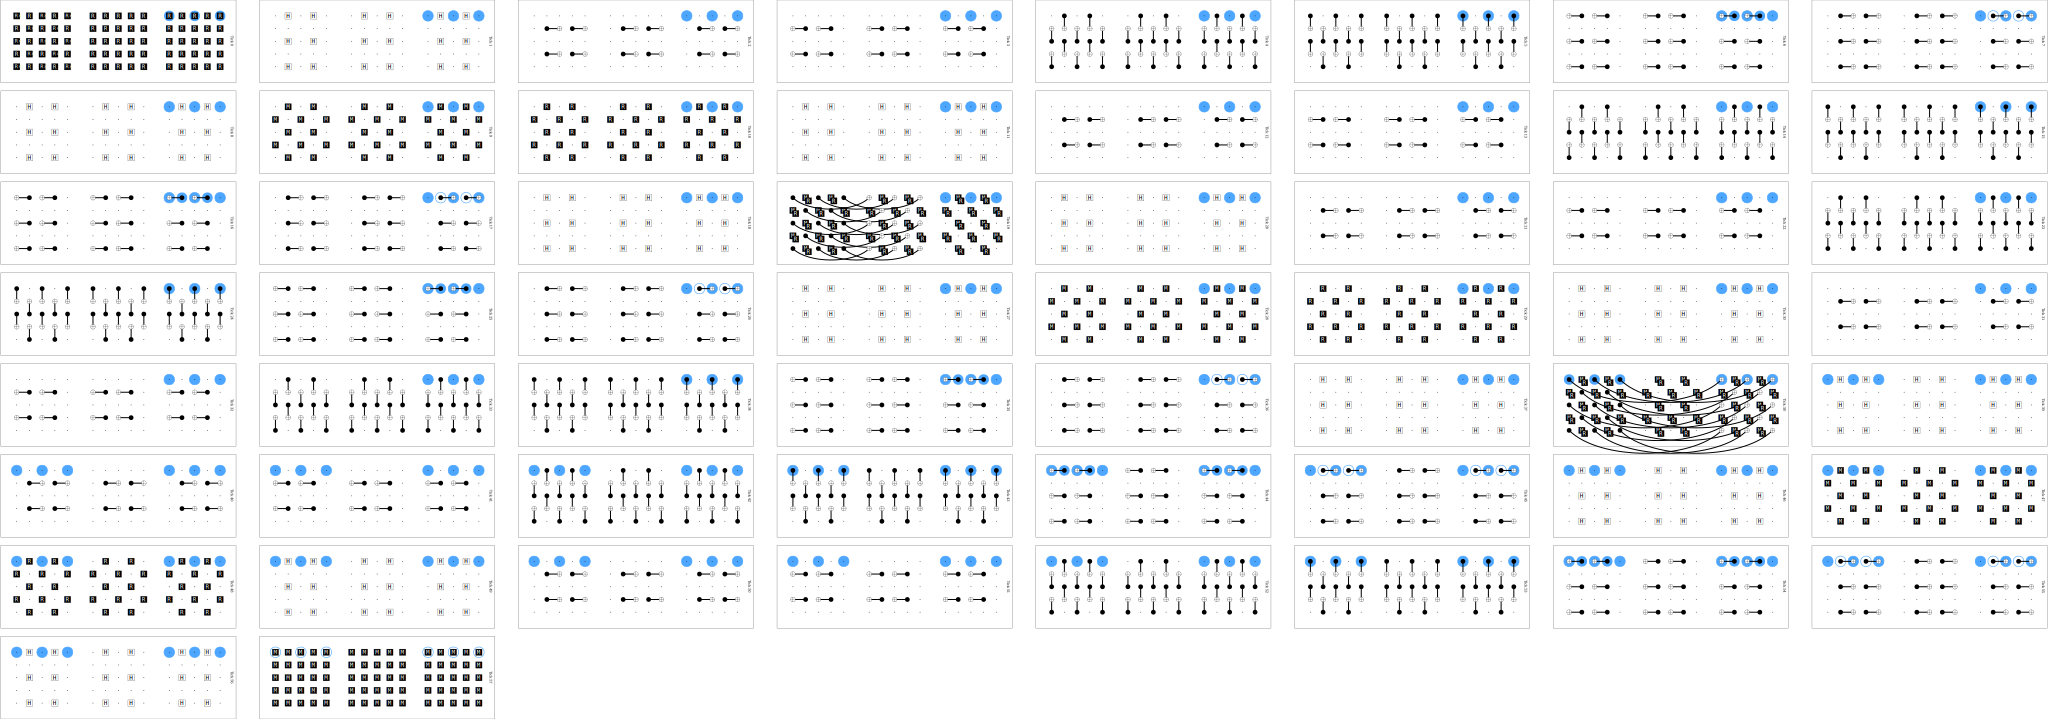

In [12]:
# -----------------------------
# Config
# -----------------------------
distance = 3

# Patch offsets (relative to patch1)
offset_patch2 = (6, 0)   # patch2 offset relative to patch1
offset_patch3 = (12, 0)   # patch3 offset relative to patch1

# Initial states: |+>, |0>, |0>
initial_basis_patch1 = "X"   # |+> state
initial_basis_patch2 = "Z"   # |0> state
initial_basis_patch3 = "Z"   # |0> state

# Measurement bases (useful test cases: X,X,X or Z,Z,Z)
# Change these to test different measurement combinations
measure_basis_patch1 = "Z"   # "X" or "Z"
measure_basis_patch2 = "Z"   # "X" or "Z"
measure_basis_patch3 = "Z"   # "X" or "Z"

rounds_before = 2   # rounds before CNOT gates
rounds_after = 2    # rounds after CNOT gates
if_detector = True

# -----------------------------
# 1) Build 3 unrotated surface-code patches and place into a system
# -----------------------------
patch1_local = UnrotatedSurfaceCode(distance=distance)
patch2_local = UnrotatedSurfaceCode(distance=distance)
patch3_local = UnrotatedSurfaceCode(distance=distance)

system = QECSystem()
# NOTE: add_patch returns global patch view (with global indices)
patch1_global = system.add_patch(patch1_local, name="patch1")
patch2_global = system.add_patch(patch2_local, name="patch2", offset=offset_patch2)
patch3_global = system.add_patch(patch3_local, name="patch3", offset=offset_patch3)

# -----------------------------
# 2) Setup tracker + builder
# -----------------------------
tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=if_detector)

builder.write_coordinates()

# -----------------------------
# 3) Initialize data qubits: |+>, |0>, |0>
# -----------------------------
init_dict = {}
for q in system.data_indices:
    owner = system.index_to_owner_map[q]
    if owner == "patch1":
        init_dict[q] = initial_basis_patch1
    elif owner == "patch2":
        init_dict[q] = initial_basis_patch2
    elif owner == "patch3":
        init_dict[q] = initial_basis_patch3

builder.initialize(init_dict=init_dict, n=system.num_qubits)

# -----------------------------
# 4) Syndrome extraction (before CNOT gates)
# -----------------------------
se_block = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se_block.circuit, rounds=rounds_before)

# -----------------------------
# 5) Transversal CNOT gates: CNOT(1,2) and CNOT(1,3)
# -----------------------------
logical_executor = LogicalExecutor(builder=builder)
logical_executor.register_op_set(UnrotatedSurfaceCode, CSSLogicalOpSet())

# CNOT(1,2): patch1 controls patch2
print("Applying CNOT(1,2)...")
logical_executor.apply_logical_operation(
    op_name="transversal_cnot",
    patches=[patch1_global, patch2_global],
)

builder.apply_syndrome_extraction(circuit_chunk=se_block.circuit, rounds=rounds_before)

# CNOT(1,3): patch1 controls patch3
print("Applying CNOT(1,3)...")
logical_executor.apply_logical_operation(
    op_name="transversal_cnot",
    patches=[patch1_global, patch3_global],
)

# -----------------------------
# 6) Syndrome extraction (after CNOT gates)
# -----------------------------
se_block = UnrotatedSurfaceCodeExtractionBlock(system)
builder.apply_syndrome_extraction(circuit_chunk=se_block.circuit, rounds=rounds_after)

# -----------------------------
# 7) Final data readout (basis selectable per patch)
# -----------------------------
measurements = {}
for q in system.data_indices:
    owner = system.index_to_owner_map[q]
    if owner == "patch1":
        measurements[q] = measure_basis_patch1
    elif owner == "patch2":
        measurements[q] = measure_basis_patch2
    elif owner == "patch3":
        measurements[q] = measure_basis_patch3

builder.apply_data_readout(final_measurements=measurements)

circuit = builder.circuit
print("--------------------------------")
print("Number of logical observables:", circuit.num_observables)
print(f"Measurement bases: patch1={measure_basis_patch1}, patch2={measure_basis_patch2}, patch3={measure_basis_patch3}")

# Visualization
circuit.diagram("detslice-with-ops-svg", filter_coords=["L1"])

In [3]:
# Test case: Measure in Z, Z, Z basis
# This should show correlations in the logical observables
print("Testing Z, Z, Z measurement...")
print("Expected: GHZ state |000> + |111> should show correlations")
circuit.detector_error_model()

Testing Z, Z, Z measurement...
Expected: GHZ state |000> + |111> should show correlations


stim.DetectorErrorModel('''
    detector(1, 0, 0) D0
    detector(3, 0, 0) D1
    detector(1, 2, 0) D2
    detector(3, 2, 0) D3
    detector(1, 4, 0) D4
    detector(3, 4, 0) D5
    detector(6, 1, 0) D6
    detector(8, 1, 0) D7
    detector(10, 1, 0) D8
    detector(6, 3, 0) D9
    detector(8, 3, 0) D10
    detector(10, 3, 0) D11
    detector(0, 7, 0) D12
    detector(2, 7, 0) D13
    detector(4, 7, 0) D14
    detector(0, 9, 0) D15
    detector(2, 9, 0) D16
    detector(4, 9, 0) D17
    shift_detectors(0, 0, 1) 0
    detector(1, 0, 0) D18
    detector(3, 0, 0) D19
    detector(0, 1, 0) D20
    detector(2, 1, 0) D21
    detector(4, 1, 0) D22
    detector(1, 2, 0) D23
    detector(3, 2, 0) D24
    detector(0, 3, 0) D25
    detector(2, 3, 0) D26
    detector(4, 3, 0) D27
    detector(1, 4, 0) D28
    detector(3, 4, 0) D29
    detector(7, 0, 0) D30
    detector(9, 0, 0) D31
    detector(6, 1, 0) D32
    detector(8, 1, 0) D33
    detector(10, 1, 0) D34
    detector(7, 2, 0) D35
    detector

In [4]:
# Test case: Measure in X, X, X basis
# To test X, X, X measurement, change the measurement bases in Cell 1 and re-run
print("To test X, X, X measurement:")
print("  1. In Cell 1, set: measure_basis_patch1 = 'X', measure_basis_patch2 = 'X', measure_basis_patch3 = 'X'")
print("  2. Re-run Cell 1")
print("\nCurrent measurement bases:")
print(f"  patch1: {measure_basis_patch1}")
print(f"  patch2: {measure_basis_patch2}")
print(f"  patch3: {measure_basis_patch3}")

To test X, X, X measurement:
  1. In Cell 1, set: measure_basis_patch1 = 'X', measure_basis_patch2 = 'X', measure_basis_patch3 = 'X'
  2. Re-run Cell 1

Current measurement bases:
  patch1: X
  patch2: X
  patch3: X


In [5]:
# Circuit summary
print("Circuit summary:")
print(f"  Number of qubits: {circuit.num_qubits}")
print(f"  Number of measurements: {circuit.num_measurements}")
print(f"  Number of detectors: {circuit.num_detectors}")
print(f"  Number of observables: {circuit.num_observables}")
print(f"\nGHZ state preparation:")
print(f"  Initial states: patch1=|+> (X), patch2=|0> (Z), patch3=|0> (Z)")
print(f"  Applied gates: CNOT(1,2), CNOT(1,3)")
print(f"  Final measurement: patch1={measure_basis_patch1}, patch2={measure_basis_patch2}, patch3={measure_basis_patch3}")

Circuit summary:
  Number of qubits: 75
  Number of measurements: 183
  Number of detectors: 144
  Number of observables: 1

GHZ state preparation:
  Initial states: patch1=|+> (X), patch2=|0> (Z), patch3=|0> (Z)
  Applied gates: CNOT(1,2), CNOT(1,3)
  Final measurement: patch1=X, patch2=X, patch3=X
